# Creating Graphs from model results

In this notebook, first the model created by model.ipynb is imported and then the visualisations are created.

## importing requried packages

In [216]:
import linopy
import pypsa

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

import cartopy
import cartopy.crs as ccrs

import networkx as nx

import atlite
from atlite.gis import ExclusionContainer, shape_availability
from rasterio.plot import show
from rasterio.crs import CRS
import rasterio as rio

from pathlib import Path
import xarray as xr

import plotly.io as pio
import plotly.offline as py

pd.options.plotting.backend = "plotly" # or "plotly" or "matplotlib"

## Importing the models

In [217]:
n = pypsa.Network("pypsa_model_n.nc") # the model without CO2 limitations
n_no_co2 = pypsa.Network("pypsa_model_n_no_co2.nc") # the model with CO2 limitation of 0

print(f"\nobjective of model n: {(n.objective / 1e9):.2f} Mrd. €")
print(f"objective of model n: {(n_no_co2.objective / 1e9):.2f} Mrd. €")

INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.5)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.5)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, sub_networks



objective of model n: 18.16 Mrd. €
objective of model n: 49.01 Mrd. €


## preparing regional data

In [218]:
# preparing the data of states of Iran (gadm)
url_gadm_local = Path("data") / "gadm_410-levels-ADM_1-IRN.gpkg"
gadm_ir = gpd.read_file(url_gadm_local)
gadm_ir["bus"] = gadm_ir.geometry.representative_point() # to be used as bus for modeling

# exclusiv economic zone (eez)
url_eez_ir_local = Path("data") / "eez_ir.gpkg"
eez_ir = gpd.read_file(url_eez_ir_local)
eez_ir["bus"] = eez_ir.geometry.representative_point() # defining the representative of eez in north and south to be used as bus for pypsa



## loads and links

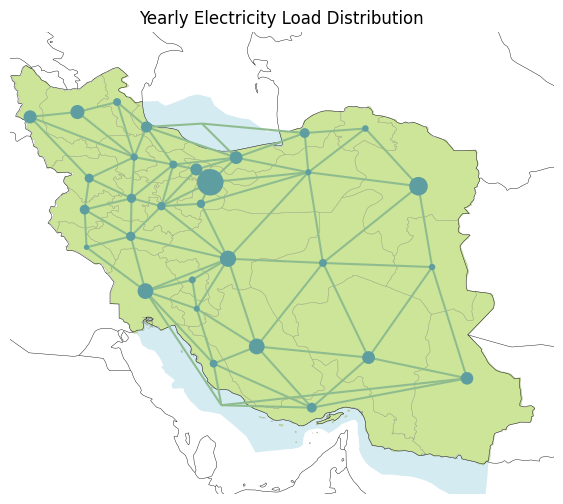

In [219]:
fig = plt.figure(figsize=(10, 6)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

load = n.loads_t.p_set.sum(axis=0).groupby(n.loads.bus).sum()
n.plot(ax=ax, bus_size=load/1e8)

ax.set_title("Yearly Electricity Load Distribution")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

In [220]:
load_ts = (n.loads_t.p_set.sum(axis=1) * n.snapshot_weightings.iloc[0, 0]).resample("D").sum()#.plot()

load_ts.divide(1e6).plot(labels=dict(value="Daily Load [TWh]"))

In [221]:
load.divide(1e6).sort_values()*3 # the load of the model is the mean for 3 hours --> Load must be multiplied with 3

bus
Ilam                           2.944117
Kohgiluyeh and Boyer-Ahmad     3.743023
Semnan                         3.881105
South Khorasan                 4.167133
North Khorasan                 4.315079
Chaharmahal and Bakhtiari      4.916724
Zanjan                         5.518369
Bushehr                        6.297549
Ardabil                        6.406043
Yazd                           6.480016
Qazvin                         6.637824
Qom                            7.170428
Markazi                        7.259196
Kurdistan                      8.329335
Hamadan                        8.723857
Lorestan                       8.837282
Kermanshah                     9.858106
Golestan                       9.941942
Hormozgan                      9.951805
Gilan                         12.669072
Alborz                        14.932639
Sistan and Baluchestan        16.175381
Kerman                        16.831273
Mazandaran                    16.841137
West Azerbaijan               17.403

In [222]:
n.snapshot_weightings.iloc[0, 0]

np.float64(3.0)

## Generation and links

### Existing Power Plants

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_33549/3946227653.py:14: DtypeWarning:

Columns (10,17,18,26,27,37,38) have mixed types. Specify dtype option on import or set low_memory=False.

/Users/morteza/DSESM-venv-312/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning:

facecolor will have no effect as it has been defined as "never".



Text(0.5, 1.0, 'Location of power plants and their primary fuel')

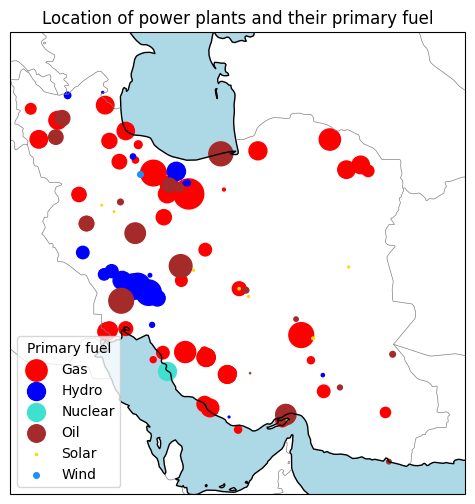

In [223]:
fuel_colors = {
    "Gas": "red",
    "Hydro": "blue",
    "Nuclear": "turquoise",
    "Oil": "brown",
    "Solar": "gold",
    "Wind": "dodgerblue",
}

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.epsg(3857))

url_power_plants = Path("data") / "global_power_plant_database.csv"
pp = pd.read_csv(url_power_plants)
pp = pp[pp["country"] == "IRN"]
geometry = gpd.points_from_xy(pp.longitude, pp.latitude) # saving geometry from long and lat of the data to create a geopanda

pp_ir = gpd.GeoDataFrame(pp, geometry=geometry, crs="WGS84")

pp_ir_3857 = pp_ir.to_crs(epsg=3857)

for fuel, color in fuel_colors.items():
    subset = pp_ir_3857[pp_ir_3857["primary_fuel"] == fuel]
    if not subset.empty:
        subset.plot(
            ax=ax,
            color=color,
            markersize=subset["capacity_mw"] / 6,
            label=fuel,
        )

ax.coastlines()
ax.add_feature(cartopy.feature.OCEAN, color="lightblue", linewidth=0.3)
ax.add_feature(cartopy.feature.BORDERS, color="grey", linewidth=0.5)

ax.legend(
    title="Primary fuel",
    loc="lower left",
    frameon=True,
)

ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())
ax.set_title("Location of power plants and their primary fuel")


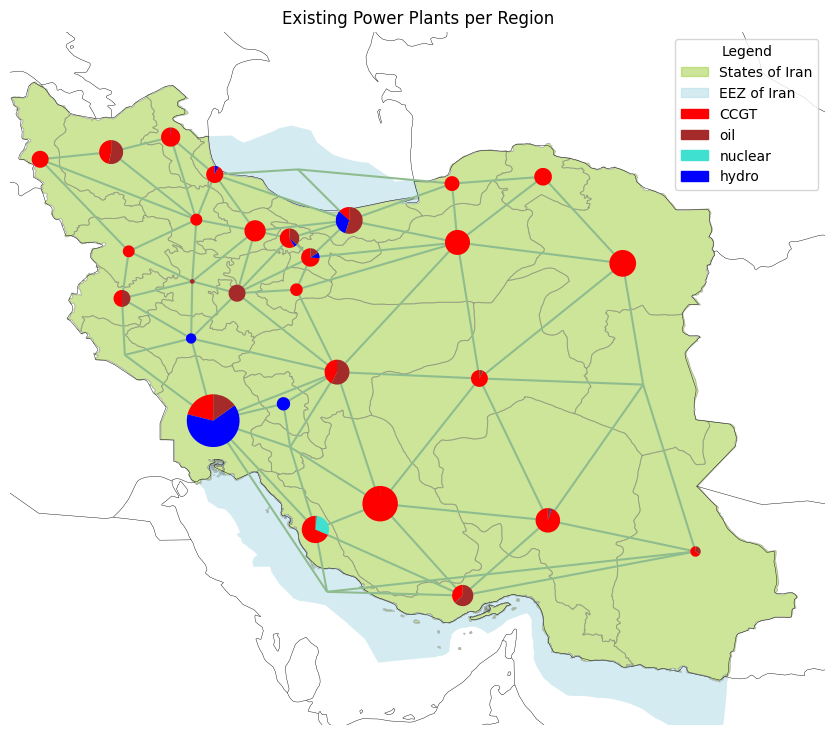

In [224]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.7)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

re_cap_potentials = n.generators.groupby(["bus", "carrier"]).p_nom.sum()
re_cap_potentials = re_cap_potentials.loc[re_cap_potentials.index.get_level_values("carrier").isin(["CCGT", "oil", "hydro", "nuclear"])]
n.plot(ax=ax, bus_size=re_cap_potentials/3e4)

ax.set_title("Existing Power Plants per Region")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

wanted_carriers = ["CCGT", "oil", "hydro", "nuclear"]

import matplotlib.patches as mpatches
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    #loc="lower left",
    frameon=True
)

### Model n (without CO2 Limit)

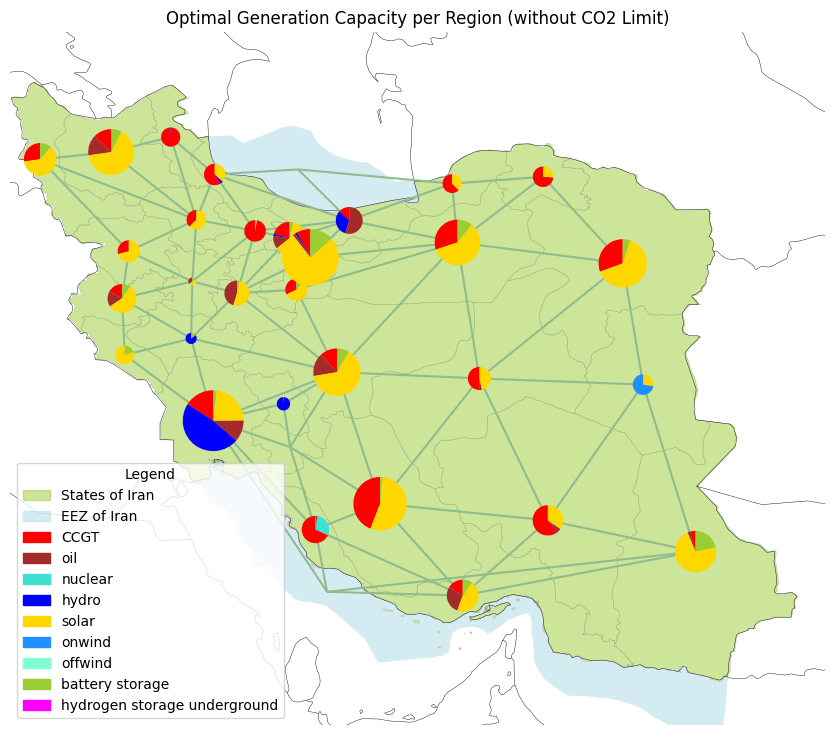

In [225]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

gen = n.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()
storages = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
capacities = pd.concat([gen, storages])
n.plot(ax=ax, bus_size=capacities/3e4)


ax.set_title("Optimal Generation Capacity per Region (without CO2 Limit)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

import matplotlib.patches as mpatches

wanted_carriers = ["CCGT", "oil", "nuclear", "hydro", "solar", "onwind", "offwind", "battery storage", "hydrogen storage underground"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    loc="lower left",
    frameon=True
)

### Model n_no_co2 (with CO2 Limit of 0)

'ax.legend(\n    handles=map_legend + carrier_legend,\n    title="Legend",\n    loc="lower left",\n    frameon=True\n)'

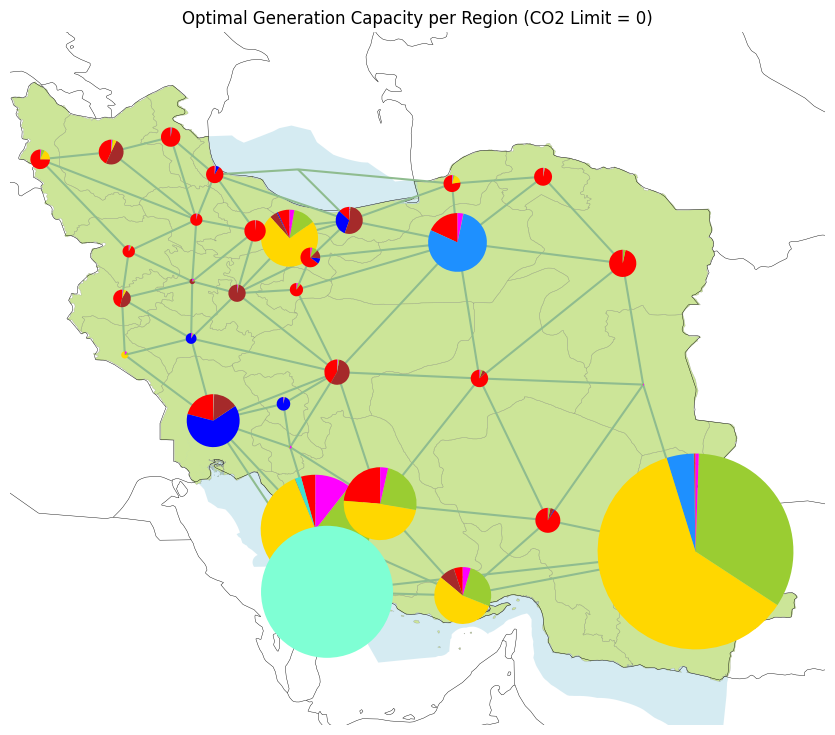

In [226]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

gen = n_no_co2.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()
storages = n_no_co2.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
capacities = pd.concat([gen, storages])

#capacities.loc[capacities.index.get_level_values("carrier").isin(["CCGT", "oil"])] = 0.0

n_no_co2.plot(ax=ax, bus_size=capacities/3e4)

ax.set_title("Optimal Generation Capacity per Region (CO2 Limit = 0)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

wanted_carriers = ["CCGT", "oil", "nuclear", "hydro", "solar", "onwind", "offwind", "battery storage", "hydrogen storage underground"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

"""ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    loc="lower left",
    frameon=True
)"""

## RE Potentials

In [227]:
re_cap_potentials = n.generators.groupby(["bus", "carrier"]).p_nom_max.mean()
re_cap_potentials = re_cap_potentials.loc[re_cap_potentials.index.get_level_values("carrier").isin(["solar", "onwind", "offwind"])]

In [228]:
re_cap_potentials.idxmin()

('Mazandaran', 'onwind')

In [229]:
#re_cap_potentials.loc[:, "solar"].sort_values()

In [230]:
re_cap_potentials.loc["Caspian Sea"]

carrier
offwind    6220.570394
Name: p_nom_max, dtype: float64

In [231]:
re_cap_potentials.loc["Mazandaran", "onwind"]

np.float64(767.4807176210561)

In [232]:
re_cap_potentials.loc["Sistan and Baluchestan", "solar"]

np.float64(383728.50838757865)

In [233]:
re_cap_potentials.loc["Sistan and Baluchestan", "onwind"]

np.float64(354857.3537591078)

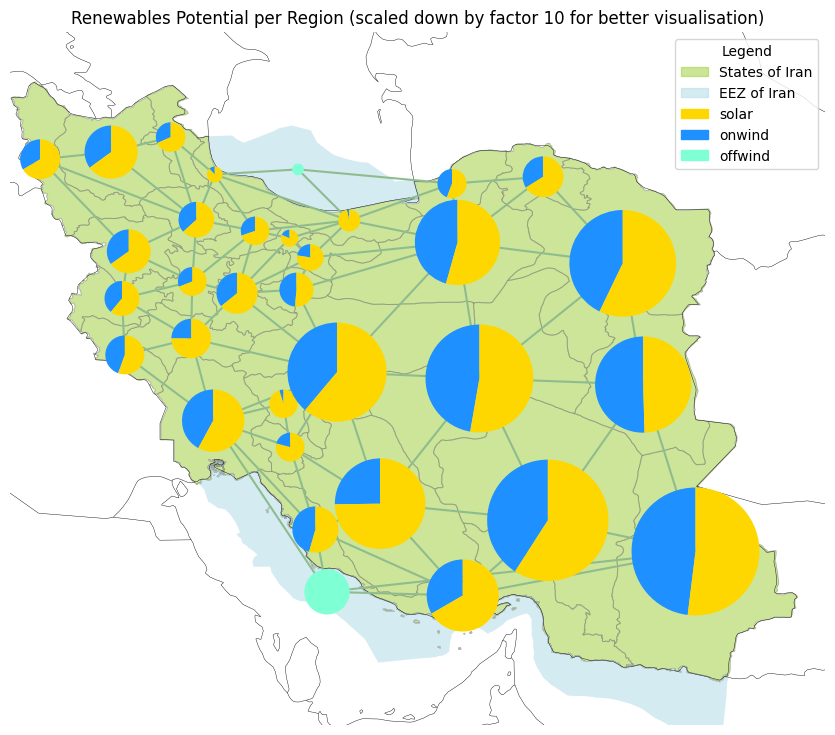

In [234]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.7)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

#re_cap_potentials = n.generators.groupby(["bus", "carrier"]).p_nom_max.mean()
#re_cap_potentials = re_cap_potentials.loc[re_cap_potentials.index.get_level_values("carrier").isin(["solar", "onwind", "offwind"])]
n.plot(ax=ax, bus_size=re_cap_potentials/3e5)

ax.set_title("Renewables Potential per Region (scaled down by factor 10 for better visualisation)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

wanted_carriers = ["solar", "onwind", "offwind"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    #loc="lower left",
    frameon=True
)

## Power Flow

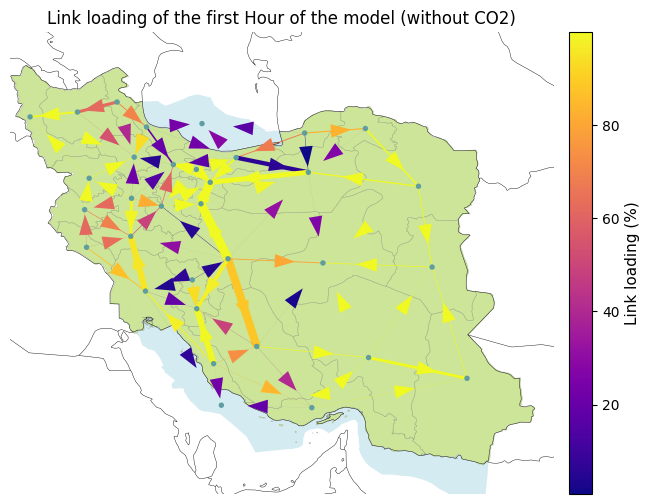

In [235]:
import numpy as np

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", alpha=0.5)

# loading showed by color
loading_pct = n.links_t.p0.iloc[0].abs() / n.links.p_nom_opt / n.links.p_max_pu * 100  # %

# widths (visible scaling)
link_w = (n.links.p_nom_opt / 1000)

# ---- pass 1: draw links (thick, no arrows) ----
n.plot(
    ax=ax,
    bus_size=1e-2,
    link_color=loading_pct,
    link_cmap="plasma",
    link_width=link_w / 1e1,     # keep line width
    link_flow=0.25,           # <-- suppress arrows
    auto_scale_branches=False,
)

import matplotlib as mpl

# --- create a ScalarMappable for the colorbar ---
norm = mpl.colors.Normalize(
    vmin=loading_pct.min(),
    vmax=loading_pct.max()
)

sm = mpl.cm.ScalarMappable(
    cmap="plasma",
    norm=norm
)
sm.set_array([])  # required for matplotlib
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.035,
    pad=0.02
)

cbar.set_label("Link loading (%)", fontsize=11)

ax.set_title("Link loading of the first Hour of the model (without CO2)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())


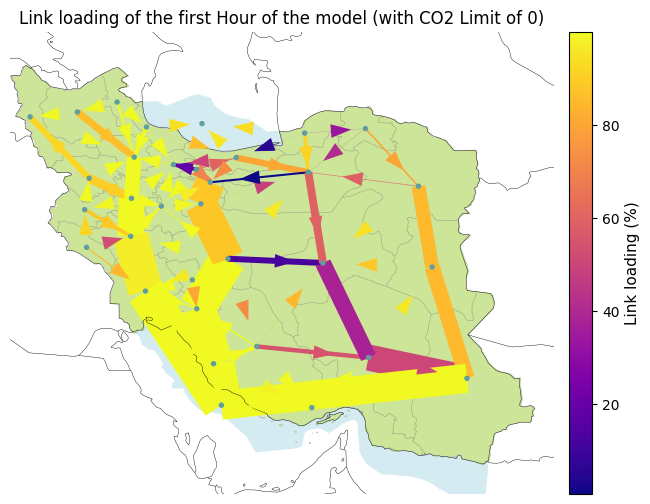

In [236]:
import numpy as np

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", alpha=0.5)

# loading showed by color
loading_pct = n_no_co2.links_t.p0.iloc[0].abs() / n_no_co2.links.p_nom_opt / n_no_co2.links.p_max_pu * 100  # %

# widths (visible scaling)
link_w = (n_no_co2.links.p_nom_opt / 1000)

# ---- pass 1: draw links (thick, no arrows) ----
n_no_co2.plot(
    ax=ax,
    bus_size=1e-2,
    link_color=loading_pct,
    link_cmap="plasma",
    link_width=link_w / 1e1,     # keep line width
    link_flow=0.25,           # <-- suppress arrows
    auto_scale_branches=False,
)

import matplotlib as mpl

# --- create a ScalarMappable for the colorbar ---
norm = mpl.colors.Normalize(
    vmin=loading_pct.min(),
    vmax=loading_pct.max()
)

sm = mpl.cm.ScalarMappable(
    cmap="plasma",
    norm=norm
)
sm.set_array([])  # required for matplotlib
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.035,
    pad=0.02
)

cbar.set_label("Link loading (%)", fontsize=11)

ax.set_title("Link loading of the first Hour of the model (with CO2 Limit of 0)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())


## Total System Cost

In [273]:
tsc_n = (
    pd.concat(
        {
            "capex": n.statistics.capex(),
            "opex": n.statistics.opex(),
        },
        axis=1,
    )
    .div(1e9)
    .round(2)
    .fillna(0.0)
)  # bn€/a

tsc_n_no_co2 = (
    pd.concat(
        {
            "capex": n_no_co2.statistics.capex(),
            "opex": n_no_co2.statistics.opex(),
        },
        axis=1,
    )
    .div(1e9)
    .round(2)
    .fillna(0.0)
)  # bn€/a

tsc_n.index = tsc_n.index.get_level_values("carrier").union(
    tsc_n_no_co2.index.get_level_values("carrier")
)

tsc_n_no_co2.index = tsc_n_no_co2.index.get_level_values("carrier").union(
    tsc_n_no_co2.index.get_level_values("carrier"))

# adding hydro to the model
tsc_n.loc["hydro", :] = 0
tsc_n_no_co2.loc["hydro", :] = 0
tsc_n_no_co2.sum().sum()

np.float64(54.269999999999996)

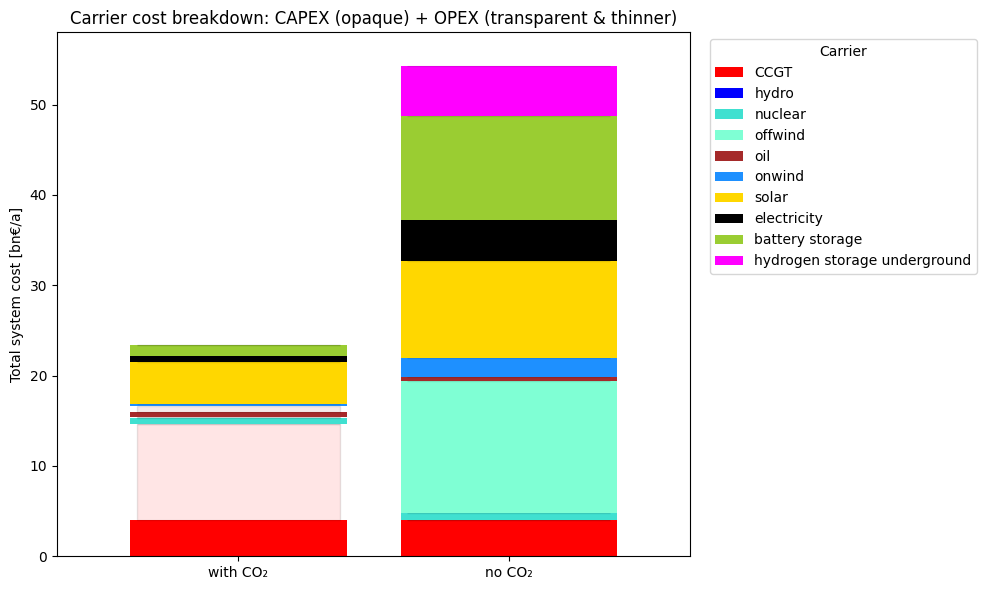

In [238]:
# --- carrier colors (PyPSA) ---
carrier_colors = n.carriers["color"]  # Series indexed by carrier

# --- make sure both tables have the same carrier index ---
carriers = tsc_n.index.get_level_values("carrier").union(
    tsc_n_no_co2.index.get_level_values("carrier")
)

# if some carriers have no defined color, give them a default
colors = {c: carrier_colors.get(c, "#999999") for c in carriers}

fig, ax = plt.subplots(figsize=(10, 6))

x = np.array([0, 1])
labels = ["with CO₂", "no CO₂"]

# bottoms for stacking
"""bottom_capex = np.zeros_like(x, dtype=float)
bottom_total = np.zeros_like(x, dtype=float)  # capex+opex stack"""

bottom = float(0)

# for model n:
for c in carriers:
        cap = tsc_n.loc[c, "capex"]
        opx = tsc_n.loc[c, "opex"]

        # 1) plot CAPEX stack (opaque)
        ax.bar(0, cap, bottom=bottom, color=colors[c], alpha=1, width=0.8)
        bottom += cap

        # 2) plot OPEX stack on top of (capex+previous opex) (transparent)
        ax.bar(0, opx, bottom=bottom, color=colors[c], alpha=0.1, width=0.75, edgecolor="black")
        bottom += opx

bottom = float(0)
# for model n_no_co2:
for c in carriers:
        cap = tsc_n_no_co2.loc[c, "capex"]
        opx = tsc_n_no_co2.loc[c, "opex"]

        # 1) plot CAPEX stack (opaque)
        ax.bar(1, cap, bottom=bottom, color=colors[c], alpha=1, width=0.8)
        bottom += cap

        # 2) plot OPEX stack on top of (capex+previous opex) (transparent)
        ax.bar(1, opx, bottom=bottom, color=colors[c], alpha=0.1, width=0.75, edgecolor="black")
        bottom += opx

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Total system cost [bn€/a]")
ax.set_title("Carrier cost breakdown: CAPEX (opaque) + OPEX (transparent & thinner)")

# legend = carriers (single entry per carrier)
handles = [mpatches.Patch(facecolor=colors[c], edgecolor="none", label=c) for c in carriers]
ax.legend(handles=handles, title="Carrier", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 58)

ax.margins(x=0.15)
plt.tight_layout()
plt.show()


In [239]:
tsc_n_no_co2

,capex,opex
carrier,,
CCGT,4.07,0.00
hydro,0.00,0.00
nuclear,0.75,0.01
offwind,14.52,0.00
oil,0.46,0.00
onwind,2.15,0.00
solar,10.75,0.00
electricity,4.55,0.00
battery storage,11.52,0.00


## Capacities built per technology

In [268]:
# generation capacities
n_capacities_per_carrier = n.generators.groupby(["carrier"]).sum().p_nom_opt.divide(1e3) # in GW
n_no_co2_capacities_per_carrier = n_no_co2.generators.groupby(["carrier"]).sum().p_nom_opt.divide(1e3) # in GW

# storage capacities
n_storage_cap = n.storage_units.groupby(["carrier"]).sum().p_nom_opt.divide(1e3) # in GW
n_no_co2_storage_cap = n_no_co2.storage_units.groupby(["carrier"]).sum().p_nom_opt.divide(1e3) # in GW

# having them all in one series
n_caps = pd.concat([n_capacities_per_carrier, n_storage_cap])  # in GW
n_no_co2_caps = pd.concat([n_no_co2_capacities_per_carrier, n_no_co2_storage_cap])  # in GW
n_caps.sum()

np.float64(145.96723141434646)

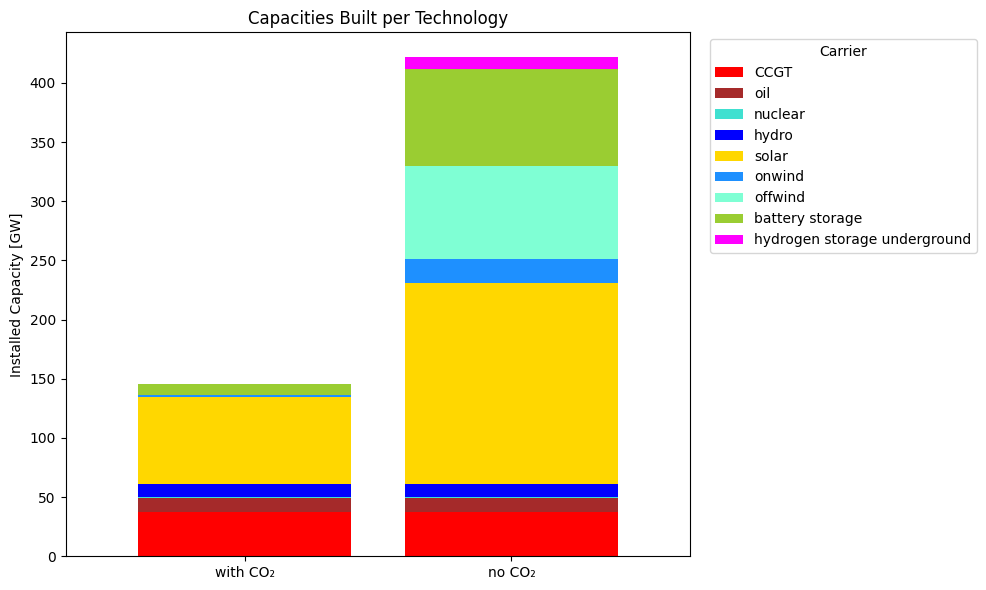

In [241]:
# --- carrier colors (PyPSA) ---
carrier_colors = n.carriers["color"]  # Series indexed by carrier

# --- make sure both tables have the same carrier index ---
carriers = n.carriers.index

# if some carriers have no defined color, give them a default
colors = {c: carrier_colors.get(c, "#999999") for c in carriers}

fig, ax = plt.subplots(figsize=(10, 6))

x = np.array([0, 1])
labels = ["with CO₂", "no CO₂"]

# bottoms for stacking
"""bottom_capex = np.zeros_like(x, dtype=float)
bottom_total = np.zeros_like(x, dtype=float)  # capex+opex stack"""

bottom = float(0)

# for model n:
for c in carriers:
        if c != "electricity":
            cap = n_caps[c]

            # 1) plot CAPEX stack (opaque)
            ax.bar(0, cap, bottom=bottom, color=colors[c], alpha=1, width=0.8)
            bottom += cap

bottom = float(0)
# for model n_no_co2:
for c in carriers:
        if c != "electricity":
            cap = n_no_co2_caps[c]

            # 1) plot CAPEX stack (opaque)
            ax.bar(1, cap, bottom=bottom, color=colors[c], alpha=1, width=0.8)
            bottom += cap

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Installed Capacity [GW]")
ax.set_title("Capacities Built per Technology")

# legend = carriers (single entry per carrier)
handles = [mpatches.Patch(facecolor=colors[c], edgecolor="none", label=c) for c in carriers if c != "electricity"]
ax.legend(handles=handles, title="Carrier", bbox_to_anchor=(1.02, 1), loc="upper left")
#ax.set_ylim(0, 420)

ax.margins(x=0.15)
plt.tight_layout()
plt.show()


## RE Time Series

In [242]:
# reading the RE generation potential data (reults of land eligibility analysis)
onwind_ts = pd.read_csv("data/wind_on_capacity_per_region_timeseries.csv", index_col=0, parse_dates=True)
offwind_ts = pd.read_csv("data/wind_off_capacity_per_region_timeseries.csv", index_col=0, parse_dates=True)
pv_ts = pd.read_csv("data/pv_capacity_per_region_timeseries.csv", index_col=0, parse_dates=True)

def make_potential_and_cf(gen_mw_df):
    p_nom_max = gen_mw_df.max(axis=0).clip(lower=0.0)                # MW
    p_max_pu  = gen_mw_df.divide(p_nom_max.replace(0.0, np.nan), axis=1).fillna(0.0)
    p_max_pu  = p_max_pu.clip(0.0, 1.0)                               # 0..1
    return p_nom_max, p_max_pu

pv_p_nom_max, pv_cf = make_potential_and_cf(pv_ts)
on_p_nom_max, on_cf = make_potential_and_cf(onwind_ts)
off_p_nom_max, off_cf = make_potential_and_cf(offwind_ts)

off_cf.resample("M").mean().plot(labels=dict(value="Capacity Factor [p.u.]"))

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_33549/3716071512.py:16: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



In [243]:
pd.options.plotting.backend = "plotly" # or "plotly" or "matplotlib"
off_cf.loc["2025-05"].plot(labels=dict(value="Capacity Factor [p.u.]"))
#off_cf.resample("D").mean().plot(labels=dict(value="Capacity Factor [p.u.]"))

In [244]:
#pv_cf.resample("M").mean().plot(labels=dict(value="Capacity Factor [p.u.]"))
pv_cf.loc["2025-05"].plot(labels=dict(value="Capacity Factor [p.u.]"))

In [245]:
#on_cf.resample("M").mean().plot(labels=dict(value="Capacity Factor [p.u.]")) # creates monthly cf for the whole year
on_cf.loc["2025-08"].resample("D").mean().plot(labels=dict(value="Capacity Factor [p.u.]"))

In [246]:
#on_cf.loc["2025-03"].resample("D").mean().plot(labels=dict(value="Capacity Factor [p.u.]")) # creates cf for only one month

## Electricity Mix

In [259]:
# generation per carrier for model n
gen_p_n = n.generators_t.p
gen_by_carr_n = gen_p_n.groupby(n.generators.carrier, axis=1).sum().sum(axis=0).divide(1e6) * n.snapshot_weightings.iloc[0, 0] # in TWh

# for the model n_no_co2
gen_p_n_no_co2 = n_no_co2.generators_t.p
gen_by_carr_n_no_co2 = gen_p_n_no_co2.groupby(n_no_co2.generators.carrier, axis=1).sum().sum(axis=0).divide(1e6) * n_no_co2.snapshot_weightings.iloc[0, 0] # in TWh

#gen_by_carr_n

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_33549/3360964689.py:3: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_33549/3360964689.py:7: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



In [262]:
gen_by_carr_n.sum()

np.float64(425.6564238262409)

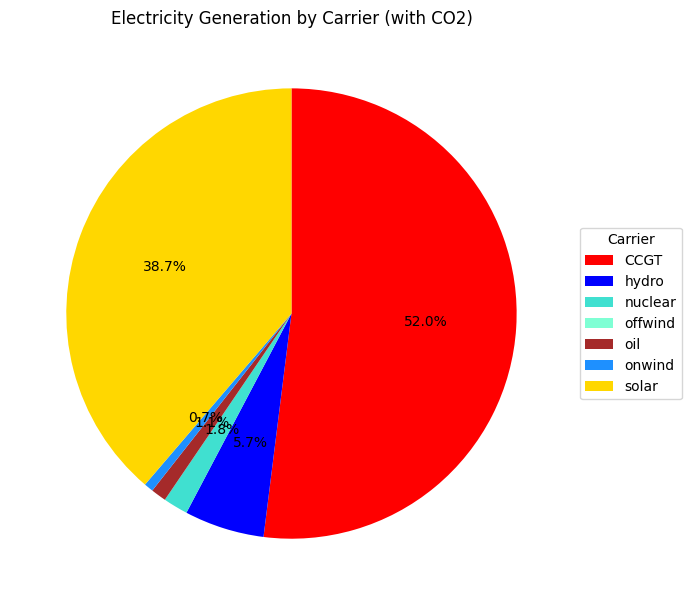

In [249]:
# Align colors with data
colors = n.carriers.color.reindex(gen_by_carr_n.index)

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    gen_by_carr_n,
    labels=None,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)

for autotext in autotexts:
    if autotext.get_text() == "0.0%":
        autotext.set_text("")

# Legend
ax.legend(
    wedges,
    gen_by_carr_n.index,
    title="Carrier",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

ax.set_title("Electricity Generation by Carrier (with CO2)")
plt.tight_layout()
plt.show()

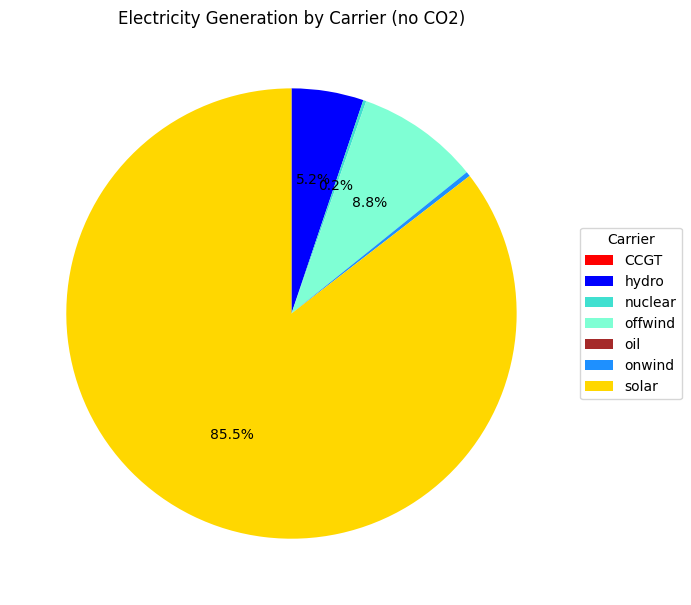

In [250]:
# Align colors with data
colors = n.carriers.color.reindex(gen_by_carr_n.index)

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    gen_by_carr_n_no_co2,
    labels=None,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)

for autotext in autotexts:
    if (autotext.get_text() == "0.0%") | (autotext.get_text() == "0.3%"):
        autotext.set_text("")

# Legend
ax.legend(
    wedges,
    gen_by_carr_n.index,
    title="Carrier",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

ax.set_title("Electricity Generation by Carrier (no CO2)")
plt.tight_layout()
plt.show()

### Regional Distribution

In [251]:
# generation per carrier for model n
gen_p_n = n.generators_t.p
gen_by_carr_n = gen_p_n.groupby([n.generators.bus, n.generators.carrier], axis=1).sum().sum(axis=0).divide(1e3) * n.snapshot_weightings.iloc[0, 0] # in GWh

# for the model n_no_co2
gen_p_n_no_co2 = n_no_co2.generators_t.p
gen_by_carr_n_no_co2 = gen_p_n_no_co2.groupby([n_no_co2.generators.bus, n.generators.carrier], axis=1).sum().sum(axis=0).divide(1e3) * n_no_co2.snapshot_weightings.iloc[0, 0] # in GWh

gen_by_carr_n

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_33549/3011562232.py:3: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

/var/folders/h3/z_4l05b96rn0jmfgxq7ty0lw0000gn/T/ipykernel_33549/3011562232.py:7: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



bus     carrier
Alborz  CCGT       6077.882230
        hydro       123.675190
        oil         463.238482
        onwind        0.006708
        solar      6262.414952
                      ...     
Yazd    onwind        0.003349
        solar      2521.400751
Zanjan  CCGT       3877.082582
        onwind        0.002332
        solar      2108.102694
Length: 114, dtype: float64

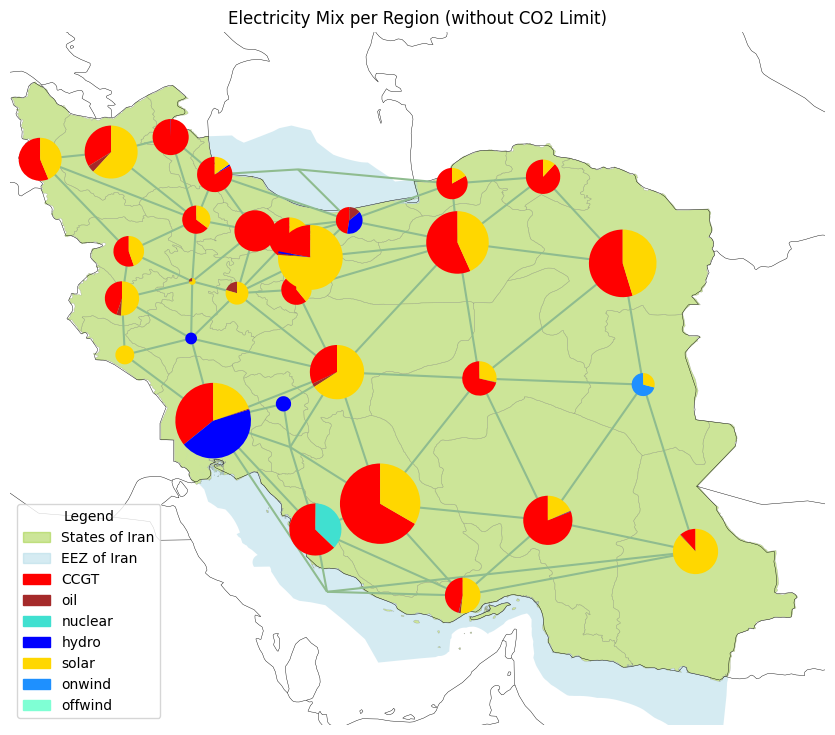

In [252]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

gen = n.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()
storages = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
capacities = pd.concat([gen, storages])
n.plot(ax=ax, bus_size=gen_by_carr_n/5e4)


ax.set_title("Electricity Mix per Region (without CO2 Limit)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

import matplotlib.patches as mpatches

wanted_carriers = ["CCGT", "oil", "nuclear", "hydro", "solar", "onwind", "offwind"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    loc="lower left",
    frameon=True
)

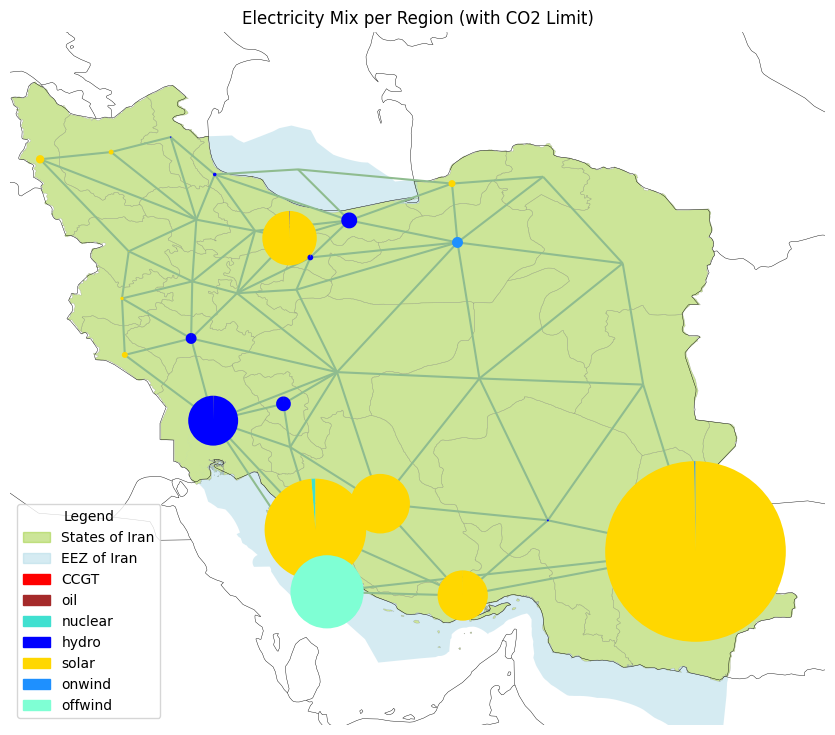

In [253]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

gen = n.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()
storages = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
capacities = pd.concat([gen, storages])
n.plot(ax=ax, bus_size=gen_by_carr_n_no_co2/5e4)


ax.set_title("Electricity Mix per Region (with CO2 Limit)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

import matplotlib.patches as mpatches

wanted_carriers = ["CCGT", "oil", "nuclear", "hydro", "solar", "onwind", "offwind"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    loc="lower left",
    frameon=True
)

In [254]:
n.links.capital_cost

name
line_Alborz__Markazi                           16358.323526
line_Alborz__Mazandaran                        13392.548961
line_Alborz__Qazvin                             7583.399549
line_Alborz__Tehran                             6097.134070
line_Ardabil__East Azerbaijan                  13200.928679
                                                   ...     
line_Semnan__Yazd                              29630.219689
line_Sistan and Baluchestan__South Khorasan    37618.332132
line_Sistan and Baluchestan__Persian Gulf      79719.364428
line_South Khorasan__Yazd                      35240.619109
line_West Azerbaijan__Zanjan                   36012.142599
Name: capital_cost, Length: 81, dtype: float64

## Energy Balance

In [255]:
n.statistics.energy_balance.iplot()

In [256]:
n_no_co2.statistics.energy_balance.iplot()